# Modelling

***Three supervised learning models are trained, tuned, and compared to predict commercial success on Steam, establishing a Ridge regression baseline before applying Random Forest and XGBoost. All experiment runs, parameters, and metrics are tracked locally via MLflow with a SQLite backend. Models are evaluated on the held out test split (2020–2023), and the best performing model is serialized for downstream SHAP analysis and Streamlit deployment.***

## Setup & Imports

***Standard data science libraries are imported alongside scikit-learn metrics and model classes, XGBoost, and MLflow for experiment tracking. The Python path is extended to allow imports from the project's `src/` directory.***

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Add the project root to python path to allow importing src
script_path = Path.cwd()
project_root = script_path.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## Data Preparation & MLflow Initialization

***MLflow tracking is configured with a local SQLite backend, storing parameters, metrics, and model artifacts for every run in `mlflow.db` at the project root. The training set (releases before 2020) and test set (releases 2020–2023) are loaded from `data/processed/`. The validation set is intentionally excluded from this notebook, it serves as an out of time holdout untouched until final evaluation, ensuring no leakage enters model selection or hyperparameter decisions.***

In [2]:
# Configure MLflow SQLite tracking database
db_path = project_root / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("steam_success_prediction")

# Load datasets
train_path = project_root / "data" / "processed" / "games_train.csv"
test_path = project_root / "data" / "processed" / "games_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Loaded Train set: {train_df.shape}")
print(f"Loaded Test set: {test_df.shape}")

Loaded Train set: (29128, 79)
Loaded Test set: (34531, 79)


### Feature Extraction & Column Exclusion

***`success_score` is separated as the target. All columns unavailable at launch or representing post launch engagement, including `Peak CCU` and `Recommendations`, which accumulate over a game's lifetime, are excluded to prevent leakage. The intermediate encoding column `primary_genre_mapped`, created during notebook 04's genre encoding step, is also dropped. Pre-fit assertions verify that neither `X_train` nor `X_test` contain missing values before any model is fitted.***

In [3]:
target_col = 'success_score'

# List columns to exclude from training
drop_cols = [
    'AppID', 'Name', 'Release date', 'Genres', 'Tags', 'About the game', 
    'Header image', 'Support email', 'Developers', 'Publishers', 
    'Categories', 'Screenshots', 'Supported languages', 'Full audio languages',
    'Positive', 'Negative', 'Review_Count', 'wilson_lb', 'success_score',
    'Min owners', 'Max owners', 'Avg owners', 'price_tier', 'primary_genre',
    'primary_genre_mapped', 'Recommendations', 'Peak CCU'
]

cols_to_drop = [c for c in drop_cols if c in train_df.columns]

X_train = train_df.drop(columns=cols_to_drop)
y_train = train_df[target_col]

X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df[target_col]

# Pre-fit NaN verification
assert X_train.isnull().sum().sum() == 0, "NaNs found in X_train"
assert X_test.isnull().sum().sum() == 0, "NaNs found in X_test"

print(f"Feature matrix shape (Train): {X_train.shape}")
print(f"Feature matrix shape (Test): {X_test.shape}")

Feature matrix shape (Train): (29128, 53)
Feature matrix shape (Test): (34531, 53)


## Baseline Model: Ridge Regression

***Ridge regression serves as the interpretable baseline, a linear model with an L2 regularisation penalty that prevents overfitting when many correlated predictors are present, such as the one-hot encoded genre dummies. A linear baseline is valuable here not because it is expected to perform well, but because it quantifies how much of the variance in `success_score` is explained by simple additive relationships alone. Any substantial improvement from the tree models in future sections will confirm that the feature-target relationship is genuinely non-linear.***

In [4]:
# Initialize Ridge baseline with default alpha
alpha = 1.0
ridge = Ridge(alpha=alpha)

### Training & MLflow Logging (Ridge)

***Ridge is fitted on the training split and evaluated on both train and test. The regularisation parameter `alpha`, RMSE, MAE, and R² for both splits are logged to MLflow.***

In [5]:
with mlflow.start_run(run_name="ridge_baseline"):
    mlflow.log_param("alpha", alpha)
    
    # Fit the model
    ridge.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = ridge.predict(X_train)
    y_test_pred = ridge.predict(X_test)
    
    # Calculate evaluation metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Log to MLflow
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    
    # Log the model binary
    mlflow.sklearn.log_model(ridge, "model")
    
    print("=== Ridge Baseline Results ===")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print(f"Train MAE:  {train_mae:.4f} | Test MAE:  {test_mae:.4f}")
    print(f"Train R2:   {train_r2:.4f} | Test R2:   {test_r2:.4f}")

2026/07/10 11:17:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Ridge Baseline Results ===
Train RMSE: 1.5104 | Test RMSE: 1.5945
Train MAE:  1.1681 | Test MAE:  1.2206
Train R2:   0.5535 | Test R2:   0.3554


***The test R² of 0.355 confirms that linear relationships account for only a modest share of the variance in `success_score`. The train/test gap is narrow, train R² 0.554 versus test R² 0.355, indicating the model is underfitting rather than overfitting: the limiting factor is model capacity, not generalisation. This result sets the performance floor that the ensemble models in sections 3 and 4 must meaningfully exceed.***

## 3. Random Forest Regressor

***Random Forest is the first ensemble model, constructing multiple decision trees on random feature subsets and averaging their predictions. Unlike Ridge, it captures non-linear relationships and feature interactions without requiring explicit transformations. Hyperparameters are tuned exhaustively via grid search cross-validation: `n_estimators` controls the ensemble size, `max_depth` limits individual tree growth to reduce overfitting, and `min_samples_split` sets the minimum sample threshold before a node is split further.***

In [6]:
# Set up the parameter search space for tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}

# Create base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

### Hyperparameter Tuning via Grid Search Cross-Validation (Random Forest)

***`GridSearchCV` exhausts all 12 combinations across the parameter grid using 3-fold cross-validation on the training split, scoring on negative mean squared error. The best estimator is retained for evaluation and MLflow logging.***

In [7]:
print("Tuning Random Forest via Grid Search...")
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

Tuning Random Forest via Grid Search...


### Training & MLflow Logging (Random Forest)

***The best estimator's parameters and evaluation metrics are committed to MLflow, and the fitted model is logged as an artifact.***

In [8]:
with mlflow.start_run(run_name="random_forest"):
    # Log hyperparameters determined by tuning
    for param, val in rf_grid.best_params_.items():
        mlflow.log_param(param, val)
        
    # Predict
    y_train_pred = best_rf.predict(X_train)
    y_test_pred = best_rf.predict(X_test)
    
    # Compute metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Log to MLflow
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(best_rf, "model")
    
    print("=== Random Forest Results ===")
    print(f"Best Hyperparameters: {rf_grid.best_params_}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print(f"Train MAE:  {train_mae:.4f} | Test MAE:  {test_mae:.4f}")
    print(f"Train R2:   {train_r2:.4f} | Test R2:   {test_r2:.4f}")

2026/07/10 11:19:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Random Forest Results ===
Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Train RMSE: 0.5867 | Test RMSE: 1.2670
Train MAE:  0.4601 | Test MAE:  1.0320
Train R2:   0.9326 | Test R2:   0.5930


***Random Forest achieves a substantial improvement over Ridge: test R² rises from 0.355 to 0.593, confirming meaningful non-linear structure in the data. However, the train/test gap is large: train R² 0.933 against test R² 0.593, reflecting significant overfitting. The selected configuration (`max_depth=20`, `min_samples_split=5`, `n_estimators=200`) allows individual trees to grow deep enough to memorise training patterns that do not generalise. XGBoost's sequential correction mechanism is expected to handle this more gracefully.***

## XGBoost Regressor

***XGBoost builds trees sequentially, each new tree is fitted to the residuals of the prior ensemble, correcting errors incrementally rather than averaging independent trees. This sequential approach, combined with regularisation through `learning_rate` and `subsample`, tends to produce better calibrated models with less overfitting than Random Forest on tabular data. The same grid search setup is applied: `n_estimators` controls the number of boosting rounds, `learning_rate` scales each tree's contribution, `max_depth` limits tree complexity, and `subsample` introduces row level stochasticity to reduce variance.***

In [9]:
# Set up the parameter search space for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.1],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0]
}
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

### Hyperparameter Tuning via Grid Search Cross-Validation (XGBoost)

***`GridSearchCV` exhausts all 16 combinations across the parameter grid using 3-fold cross-validation on the training split. The best estimator is retained for evaluation and MLflow logging.***

In [10]:
print("Tuning XGBoost via Grid Search...")
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_params,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

Tuning XGBoost via Grid Search...


### Training & MLflow Logging (XGBoost)

***The tuned XGBoost model's parameters and evaluation metrics are committed to MLflow, and the fitted model is logged as an artifact.***

In [11]:
with mlflow.start_run(run_name="xgboost"):
    # Log hyperparameters determined by tuning
    for param, val in xgb_grid.best_params_.items():
        mlflow.log_param(param, val)
        
    # Predict
    y_train_pred = best_xgb.predict(X_train)
    y_test_pred = best_xgb.predict(X_test)
    
    # Compute metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Log to MLflow
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.xgboost.log_model(best_xgb, "model")
    
    print("=== XGBoost Results ===")
    print(f"Best Hyperparameters: {xgb_grid.best_params_}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print(f"Train MAE:  {train_mae:.4f} | Test MAE:  {test_mae:.4f}")
    print(f"Train R2:   {train_r2:.4f} | Test R2:   {test_r2:.4f}")

2026/07/10 11:19:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== XGBoost Results ===
Best Hyperparameters: {'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Train RMSE: 1.0012 | Test RMSE: 1.1888
Train MAE:  0.7882 | Test MAE:  0.9567
Train R2:   0.8038 | Test R2:   0.6417


***XGBoost produces the best test performance of the three models: test R² 0.642, test RMSE 1.189, while exhibiting a more controlled train/test gap than Random Forest: train R² 0.804 versus test R² 0.642. The selected configuration (`learning_rate=0.03`, `max_depth=7`, `n_estimators=200`, `subsample=0.8`) trades raw training accuracy for better generalisation, consistent with XGBoost's design as a regularised boosting method. This model is carried forward as the best candidate for SHAP analysis.***

## Model Comparison & Leaderboard

***A comparison table is constructed across all three models, reporting train R², test RMSE, test MAE, and test R² side by side. Including train R² alongside test metrics makes the overfitting signature immediately visible: a high train R² combined with a substantially lower test R² indicates a model that has memorised the training distribution rather than generalised from it.***

In [12]:
models = {
    'Ridge Baseline': ridge,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

results = []
for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_r2 = r2_score(y_train, y_train_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    results.append({
        'Model': name,
        'Train R2': train_r2,
        'Test RMSE': rmse,
        'Test MAE': mae,
        'Test R2': r2
    })
    
df_comparison = pd.DataFrame(results)
print("Model Comparison Leaderboard:")
print(df_comparison)

Model Comparison Leaderboard:
            Model  Train R2  Test RMSE  Test MAE   Test R2
0  Ridge Baseline  0.553482   1.594500  1.220571  0.355445
1   Random Forest  0.932630   1.267045  1.032018  0.593000
2         XGBoost  0.803799   1.188783  0.956675  0.641726


***The leaderboard confirms XGBoost as the best performing model on the held out test split across all metrics. Random Forest's large train/test R² gap (0.933 vs 0.593) marks it as the most overfit of the three. Ridge's narrow gap (0.554 vs 0.355) indicates underfitting, the linear model lacks the capacity to capture the non-linear structure in the data. XGBoost strikes the best balance, though a test R² of 0.642 still leaves meaningful unexplained variance, likely attributable to unobserved signals such as marketing spend and external community activity absent from the feature set.***

### Overfitting Analysis: Train vs Test R²

***A grouped bar chart compares train and test R² for each model, making the generalisation gap immediately visible. A large gap between a model's train and test bars indicates overfitting.***

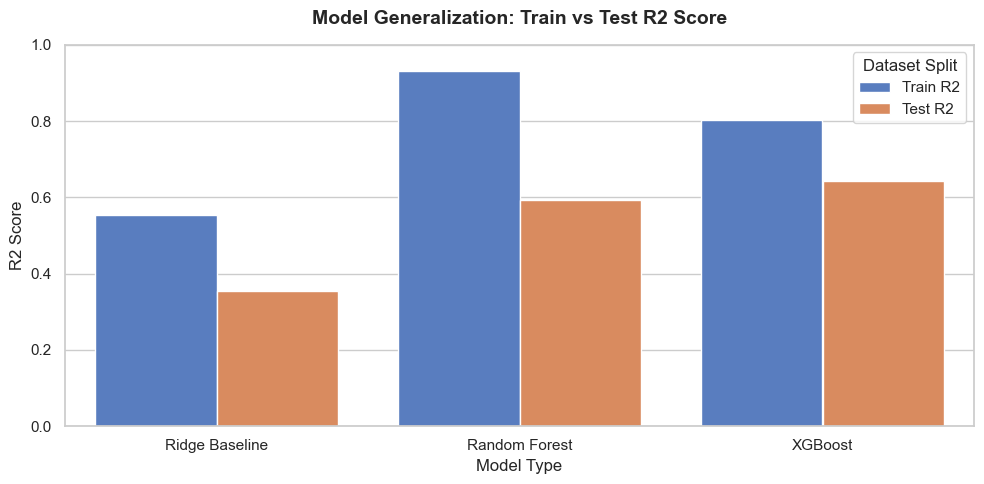

In [ ]:
# Melt the comparison dataframe to plot Train R2 and Test R2 side by side
df_melted = df_comparison.melt(
    id_vars='Model', 
    value_vars=['Train R2', 'Test R2'], 
    var_name='Split', 
    value_name='R2 Score'
)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_melted, x='Model', y='R2 Score', hue='Split', palette='muted')
plt.title('Model Generalization: Train vs Test R2 Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Dataset Split', frameon=True)
plt.tight_layout()
plt.show()

### Visual Leaderboard: Test R² by Model

***The bar chart below ranks all three models by test R², making the performance progression from linear baseline to gradient-boosted ensemble immediately visible.***

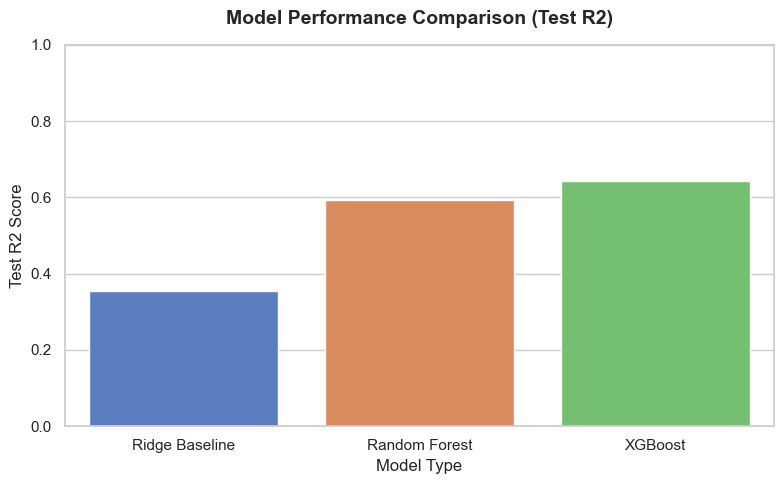

In [14]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_comparison, x='Model', y='Test R2', hue='Model', legend=False, palette='muted')
plt.title('Model Performance Comparison (Test R2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Test R2 Score', fontsize=12)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Model Serialization & Export

***The best performing model based on test R² is selected. The model object is serialized to `models/best_model.joblib`. To ensure the downstream evaluation and Streamlit application reconstruct the feature matrix in the correct order, the list of training feature names is also serialized to `models/feature_names.joblib`.***

In [15]:
best_row = df_comparison.sort_values(by='Test R2', ascending=False).iloc[0]
best_name = best_row['Model']
best_model_obj = models[best_name]

models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)
export_path = models_dir / "best_model.joblib"
joblib.dump(best_model_obj, export_path)

# Export feature columns order
feature_names_path = models_dir / "feature_names.joblib"
joblib.dump(X_train.columns.tolist(), feature_names_path)

print(f"Best model ({best_name}) successfully exported to {export_path}")
print(f"Feature column order successfully exported to {feature_names_path}")

Best model (XGBoost) successfully exported to /Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/models/best_model.joblib
Feature column order successfully exported to /Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/models/feature_names.joblib
